# 近赤外スペクトル分析チャレンジ EDA

木材近赤外スペクトルから含水率を予測するための初期EDAです。生データは `data/raw/`、出力は `outputs/experiments/EDA-001/` に保存します。

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.competition_io import read_csv_with_fallback, find_spectral_columns

sns.set_theme(style='whitegrid')
train = read_csv_with_fallback(ROOT / 'data/raw/train.csv')
test = read_csv_with_fallback(ROOT / 'data/raw/test.csv')
spectral_columns = find_spectral_columns(train.columns)
wavelengths = [float(c) for c in spectral_columns]
train.shape, test.shape, len(spectral_columns), (min(wavelengths), max(wavelengths))

((1322, 1559), (550, 1558), 1555, (3999.82139, 9993.76781))

## 樹種分布

train/testで樹種が完全に分かれているかを確認します。未知樹種への汎化が重要なので、主CVは `species number` のGroupKFoldにします。

In [2]:
species_counts = pd.concat([
    train.groupby(['species number', '樹種']).size().rename('train_count'),
    test.groupby(['species number', '樹種']).size().rename('test_count'),
], axis=1).fillna(0).astype(int)
species_counts

,,train_count,test_count
species number,樹種,,
1,イチョウ,94,0
3,ウエンジ,87,0
4,ウォールナット,110,0
5,クリ,91,0
8,スプルース,97,0
11,チェリー,88,0
12,トチ,183,0
13,ナラ,107,0
14,ヒノキ,141,0


count    1322.000000
mean       49.937672
std        49.543466
min         0.840336
25%        16.114458
50%        29.052870
75%        70.264035
max       298.581560
Name: 含水率, dtype: float64

/tmp/ipykernel_4118536/3513725003.py:7: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4118536/3513725003.py:7: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_4118536/3513725003.py:7: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/taisei/Spectral_analysis/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/taisei/Spectral_analysis/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/taisei/Spectral_analysis/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 29575 (\

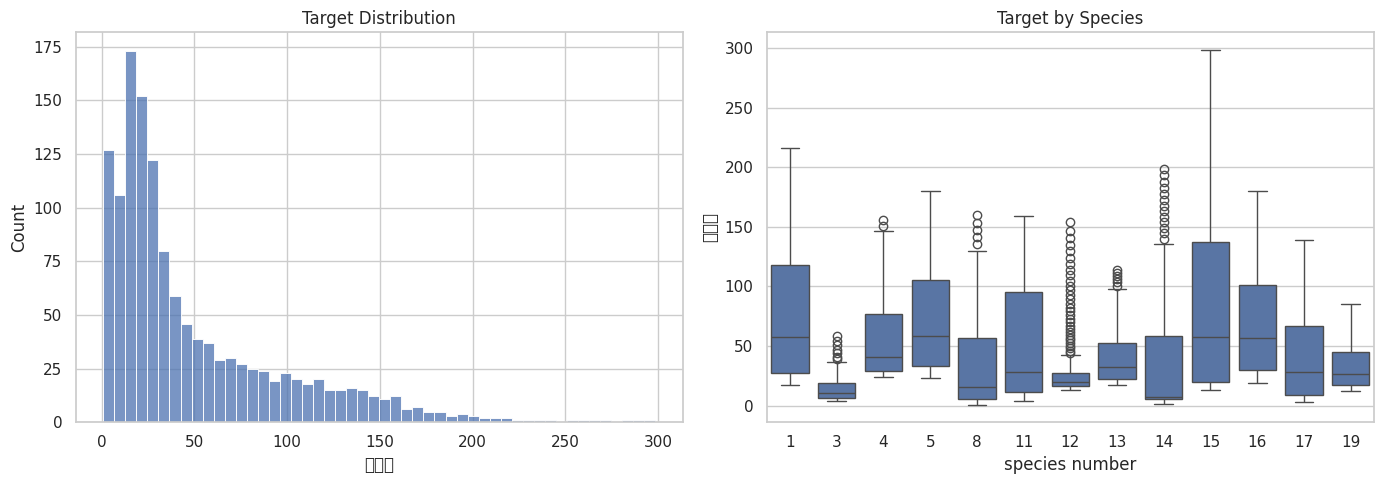

In [3]:
display(train['含水率'].describe())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['含水率'], bins=50, ax=axes[0])
sns.boxplot(data=train, x='species number', y='含水率', ax=axes[1])
axes[0].set_title('Target Distribution')
axes[1].set_title('Target by Species')
fig.tight_layout()

## スペクトル概観

水の近赤外吸収に関係する 6900 cm^-1 と 5200 cm^-1 付近を含むため、前処理後のバンド統計量も特徴量にします。

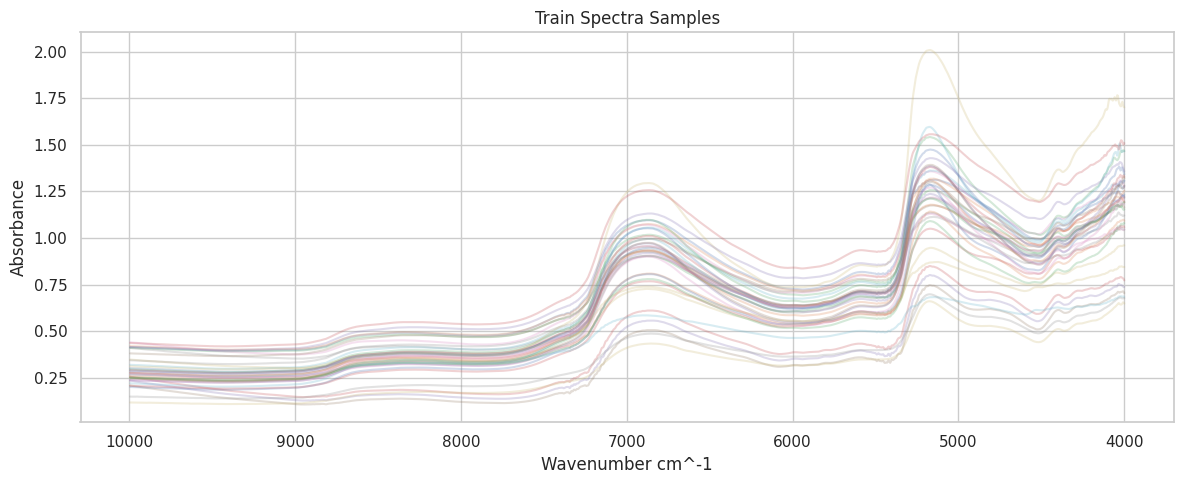

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for _, row in train.groupby('species number').head(3).iterrows():
    ax.plot(wavelengths, row[spectral_columns].to_numpy(dtype=float), alpha=0.25)
ax.invert_xaxis()
ax.set_title('Train Spectra Samples')
ax.set_xlabel('Wavenumber cm^-1')
ax.set_ylabel('Absorbance')
fig.tight_layout()

In [5]:
# 同じ内容を再現可能なEDA成果物として保存する場合
# !python ../scripts/make_eda_report.py